## A Multi-Stage Analysis of the DASS-42 Scale
This project focuses on analyzing the DASS surveys results made publically available by Openpsychometrics.org.
The objective is to identify demographic trends, correlate personality traits with mental health indicators, and evaluate the predictive power of machine learning models in identifying psychological distress.
 It is divided into three sections:
1. Exploring and Visualizing Data Demographics
2. Exploring and Visualizing Big Five Personality Dimensions
3. Predicting with Machine Learning

In [1]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


Data prepping

In [2]:
#importing modules

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DASS_Data = pd.read_csv('data.csv', sep='\t')

# Saving file back as a CSV.
# added index=False so that it prevents Pandas from adding an extra 'unnamed' column for row numbers.
DASS_Data.to_csv('DASS_Data.csv', index=False)

In [3]:
DASS_Data.head()

,Q1A,Q1I,Q1E,Q2A,Q2I,Q2E,Q3A,Q3I,Q3E,Q4A,...,screensize,uniquenetworklocation,hand,religion,orientation,race,voted,married,familysize,major
0,4,28,3890,4,25,2122,2,16,1944,4,...,1,1,1,12,1,10,2,1,2,NaN
1,4,2,8118,1,36,2890,2,35,4777,3,...,2,1,2,7,0,70,2,1,4,NaN
2,3,7,5784,1,33,4373,4,41,3242,1,...,2,1,1,4,3,60,1,1,3,NaN
3,2,23,5081,3,11,6837,2,37,5521,1,...,2,1,2,4,5,70,2,1,5,biology
4,2,36,3215,2,13,7731,3,5,4156,4,...,2,2,3,10,1,10,2,1,4,Psychology


In [4]:
DASS_Data.tail()

,Q1A,Q1I,Q1E,Q2A,Q2I,Q2E,Q3A,Q3I,Q3E,Q4A,...,screensize,uniquenetworklocation,hand,religion,orientation,race,voted,married,familysize,major
39770,2,31,3287,1,5,2216,3,29,3895,2,...,2,1,1,2,4,60,2,1,2,NaN
39771,3,14,4792,4,41,2604,3,15,2668,4,...,1,1,1,10,0,10,2,1,4,Mathematic
39772,2,1,25147,1,4,4555,2,14,3388,1,...,2,1,1,7,1,30,1,2,3,Computer Science
39773,3,36,4286,1,34,2736,2,10,5968,2,...,2,1,1,6,1,60,1,1,2,History
39774,2,28,32251,1,22,3317,2,4,11734,1,...,1,1,1,10,1,10,1,1,4,Cognitive Science


In [5]:
DASS_Data = DASS_Data.query('age < 101')

In [6]:
DASS_Data = DASS_Data[DASS_Data.VCL6 != 1]
DASS_Data = DASS_Data[DASS_Data.VCL9 != 1]
DASS_Data = DASS_Data[DASS_Data.VCL12 != 1]

In [7]:
DASS_Data.describe()

,Q1A,Q1I,Q1E,Q2A,Q2I,Q2E,Q3A,Q3I,Q3E,Q4A,...,age,screensize,uniquenetworklocation,hand,religion,orientation,race,voted,married,familysize
count,34576.000000,34576.000000,3.457600e+04,34576.000000,34576.000000,3.457600e+04,34576.000000,34576.000000,3.457600e+04,34576.000000,...,34576.000000,34576.000000,34576.000000,34576.000000,34576.000000,34576.000000,34576.000000,34576.000000,34576.000000,34576.000000
mean,2.622715,21.561372,7.222399e+03,2.167197,21.240543,5.394705e+03,2.213298,21.562760,7.724212e+03,1.932381,...,23.288408,1.260528,1.206993,1.127285,7.728048,1.633445,30.030079,1.713240,1.151753,3.557815
std,1.027480,12.132872,9.282452e+04,1.108234,12.151012,2.601595e+04,1.031141,12.102247,1.700651e+05,1.032570,...,8.345303,0.438929,0.405157,0.383191,3.469732,1.361577,25.689378,0.470497,0.434744,2.117683
min,1.000000,1.000000,1.800000e+02,1.000000,1.000000,1.760000e+02,1.000000,1.000000,-1.081400e+04,1.000000,...,13.000000,1.000000,1.000000,0.000000,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000
25%,2.000000,11.000000,2.694000e+03,1.000000,11.000000,2.520000e+03,1.000000,11.000000,2.892000e+03,1.000000,...,18.000000,1.000000,1.000000,1.000000,4.000000,1.000000,10.000000,1.000000,1.000000,2.000000
50%,3.000000,22.000000,3.648000e+03,2.000000,21.000000,3.563000e+03,2.000000,22.000000,3.942000e+03,2.000000,...,21.000000,1.000000,1.000000,1.000000,10.000000,1.000000,10.000000,2.000000,1.000000,3.000000
75%,4.000000,32.000000,5.425000e+03,3.000000,32.000000,5.300000e+03,3.000000,32.000000,5.832000e+03,3.000000,...,25.000000,2.000000,1.000000,1.000000,10.000000,2.000000,60.000000,2.000000,1.000000,5.000000
max,4.000000,42.000000,1.210228e+07,4.000000,42.000000,2.161057e+06,4.000000,42.000000,2.858269e+07,4.000000,...,99.000000,2.000000,2.000000,3.000000,12.000000,5.000000,70.000000,2.000000,3.000000,133.000000


## I. Exploring and Visualizing Data Demographics

### Demographics

/tmp/ipython-input-945309082.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.countplot(data=plot_df, x='gender_name',


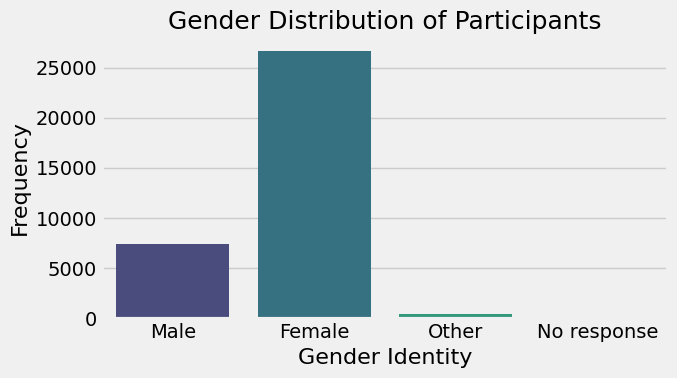

In [8]:
# 2. Data Preparation (Mapping numbers to names)
# According to the codebook: 1=Male, 2=Female, 3=Other, 0=No response
gender_map = {1: 'Male', 2: 'Female', 3: 'Other', 0: 'No response'}

# ignoring any 'age' values in this column
plot_df = DASS_Data[DASS_Data['gender'].isin([0, 1, 2, 3])].copy()
plot_df['gender_name'] = plot_df['gender'].map(gender_map)

# 3. Visualization
plt.style.use('fivethirtyeight')
plt.figure(figsize=(7,4))

g = sns.countplot(data=plot_df, x='gender_name',
                  order=['Male', 'Female', 'Other', 'No response'],
                  palette='viridis')

plt.title('Gender Distribution of Participants', fontsize=18)
plt.xlabel('Gender Identity', fontsize=16)
plt.ylabel('Frequency', fontsize=16)

plt.tight_layout()
plt.show()

/tmp/ipython-input-3222751240.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=DASS_Data, x='age_group', palette='viridis')


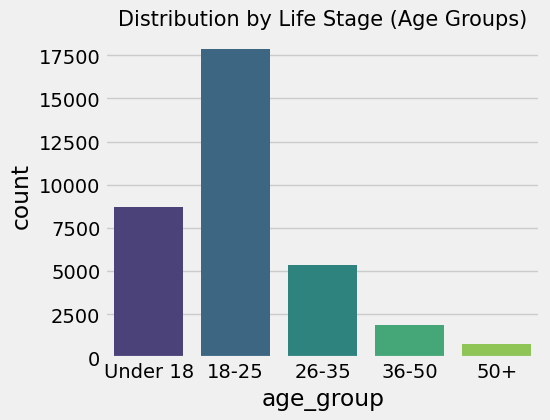

In [9]:
# --- 2. AGE ANALYSIS ---
age_bins = [0, 18, 25, 35, 50, 100]
age_labels = ['Under 18', '18-25', '26-35', '36-50', '50+']
DASS_Data['age_group'] = pd.cut(DASS_Data['age'], bins=age_bins, labels=age_labels)

# 3. Visualization
plt.style.use('fivethirtyeight')
plt.figure(figsize=(5,4))

sns.countplot(data=DASS_Data, x='age_group', palette='viridis')
plt.title('Distribution by Life Stage (Age Groups)', fontsize=15)
plt.show()

[Text(0, 0, 'Asian'),
 Text(0, 1, 'White'),
 Text(0, 2, 'Other'),
 Text(0, 3, 'Black'),
 Text(0, 4, 'Arab'),
 Text(0, 5, 'Native American'),
 Text(0, 6, 'Other')]

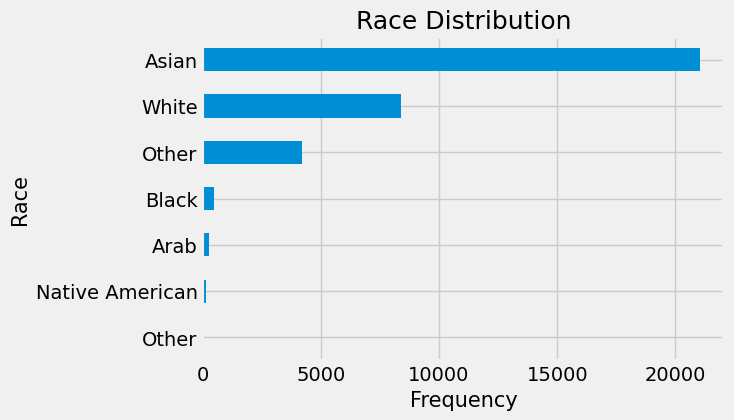

In [10]:
fig = plt.figure(figsize = (6, 4))
ax = DASS_Data['race'].value_counts().plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Race Distribution", fontsize = 18)
plt.xlabel("Frequency", fontsize = 15)
plt.ylabel("Race", fontsize = 15)
labels = ['Asian', 'White', 'Other', 'Black', 'Arab', 'Native American', 'Other']
ax.set_yticklabels(labels)

Text(0, 0.5, 'Countries')

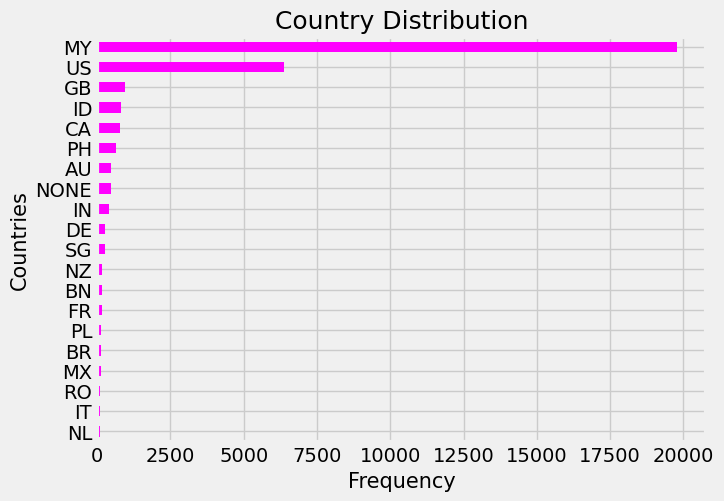

In [11]:
#plotting the 20 most frequently mentioned countries
top20countries = DASS_Data['country'].value_counts()[0:20]
plt.style.use('fivethirtyeight')
fig = plt.figure(figsize = (7, 5))
ax = top20countries.plot(kind='barh', color = 'magenta')
plt.gca().invert_yaxis()
plt.title("Country Distribution", fontsize = 18)
plt.xlabel("Frequency", fontsize = 15)
plt.ylabel("Countries", fontsize = 15)

[Text(0, 0, 'Less than high school'),
 Text(0, 1, 'High school'),
 Text(0, 2, 'University degree'),
 Text(0, 3, 'Graduate degree'),
 Text(0, 4, 'No response')]

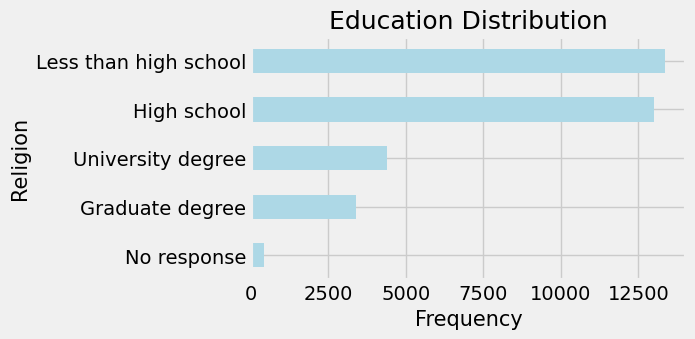

In [12]:
plt.style.use('fivethirtyeight')
fig = plt.figure(figsize = (5,3))
ax = DASS_Data['education'].value_counts().plot(kind='barh', color = 'lightblue')
plt.gca().invert_yaxis()
plt.title("Education Distribution", fontsize = 18)
plt.xlabel("Frequency", fontsize = 15)
plt.ylabel("Religion", fontsize = 15)
labels = ["Less than high school", "High school", "University degree", "Graduate degree", 'No response']
ax.set_yticklabels(labels)

[Text(0, 0, 'Muslim'),
 Text(0, 1, 'Atheist'),
 Text(0, 2, 'Agnostic'),
 Text(0, 3, 'Christian (Catholic)'),
 Text(0, 4, 'Christian (Other)'),
 Text(0, 5, 'Other'),
 Text(0, 6, 'Christian (Protestant)'),
 Text(0, 7, 'Hindu'),
 Text(0, 8, 'Buddhist'),
 Text(0, 9, 'No response'),
 Text(0, 10, 'Jewish'),
 Text(0, 11, 'Christian (Mormon)'),
 Text(0, 12, 'Sikh')]

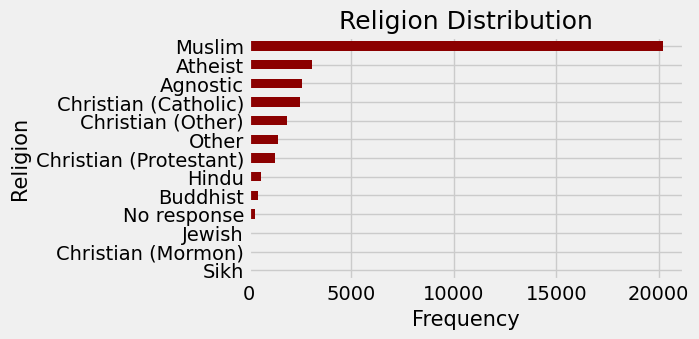

In [13]:
fig = plt.figure(figsize = (5,3))
ax = DASS_Data['religion'].value_counts().plot(kind='barh', color = 'darkred')
plt.gca().invert_yaxis()
plt.title("Religion Distribution", fontsize = 18)
plt.xlabel("Frequency", fontsize = 15)
plt.ylabel("Religion", fontsize = 15)
labels = ['Muslim', 'Atheist', 'Agnostic', 'Christian (Catholic)', 'Christian (Other)', 'Other', 'Christian (Protestant)', 'Hindu', 'Buddhist', 'No response', 'Jewish', 'Christian (Mormon)', 'Sikh']
ax.set_yticklabels(labels)

[Text(0, 0, 'Never married'),
 Text(0, 1, 'Currently married'),
 Text(0, 2, 'Previously married'),
 Text(0, 3, 'No response')]

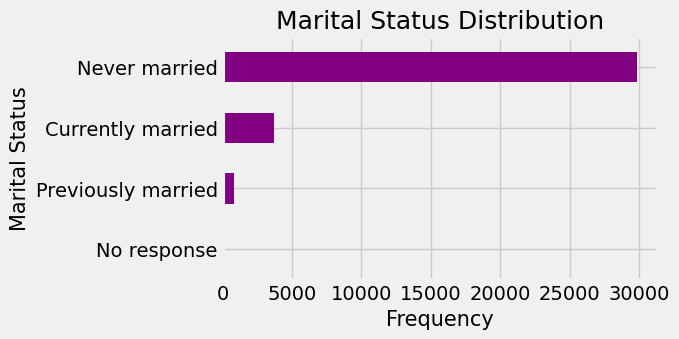

In [14]:
fig = plt.figure(figsize = (5,3))
ax = DASS_Data['married'].value_counts().plot(kind='barh', color = 'purple')
plt.gca().invert_yaxis()
plt.title("Marital Status Distribution", fontsize = 18)
plt.xlabel("Frequency", fontsize = 15)
plt.ylabel("Marital Status", fontsize = 15)
labels = ['Never married', 'Currently married', 'Previously married', 'No response']
ax.set_yticklabels(labels)

[Text(0, 0, 'Heterosexual'),
 Text(0, 1, 'Bisexual'),
 Text(0, 2, 'Other'),
 Text(0, 3, 'No response'),
 Text(0, 4, 'Asexual'),
 Text(0, 5, 'Homosexual')]

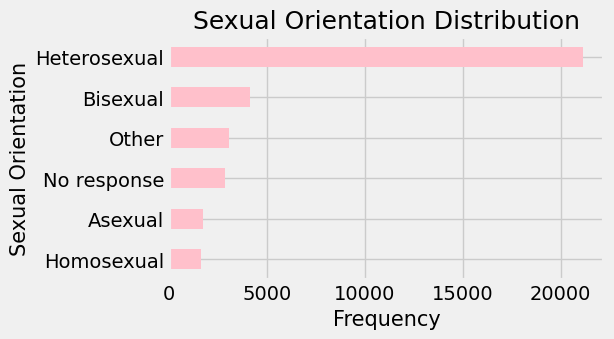

In [15]:
fig = plt.figure(figsize = (5,3))
ax = DASS_Data['orientation'].value_counts().plot(kind='barh', color = 'pink')
plt.gca().invert_yaxis()
plt.title("Sexual Orientation Distribution", fontsize = 18)
plt.xlabel("Frequency", fontsize = 15)
plt.ylabel("Sexual Orientation", fontsize = 15)
labels = ['Heterosexual', 'Bisexual', 'Other', 'No response', 'Asexual', 'Homosexual']
ax.set_yticklabels(labels)

[Text(0, 0, 'Urban (town, city)'),
 Text(0, 1, 'Suburban'),
 Text(0, 2, 'Rural (country side)'),
 Text(0, 3, 'No response')]

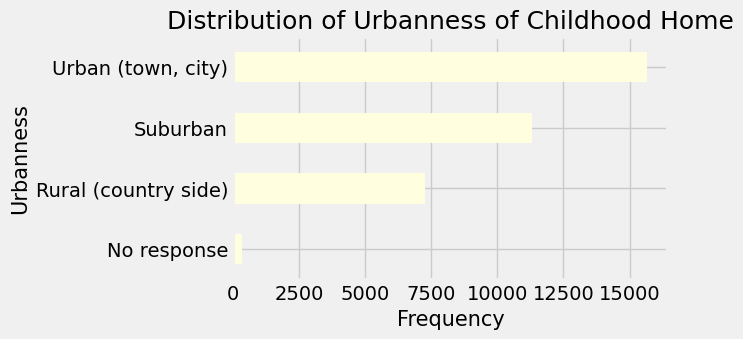

In [16]:
fig = plt.figure(figsize = (5,3))
ax = DASS_Data['urban'].value_counts().plot(kind='barh', color = 'lightyellow')
plt.gca().invert_yaxis()
plt.title("Distribution of Urbanness of Childhood Home", fontsize = 18)
plt.xlabel("Frequency", fontsize = 15)
plt.ylabel("Urbanness", fontsize = 15)
labels = ['Urban (town, city)', 'Suburban', 'Rural (country side)', 'No response']
ax.set_yticklabels(labels)

## II. Exploring and Visualizing Big Five Personality Dimensions

A quick look at the TIPI scores reveals that they represent the Big Five personality traits (openness, conscientiousness, extraversion, agreeableness, and neuroticism), with each item representing the opposite extreme of a trait dimension. TIPI results can be adjusted to provide Big Five scores for each responder, which can then be extrapolated to the demographic level.

Because these objects were evaluated on a likert scale, they need to be reversed before combining them with their counterparts. Once this is achieved, a feature for each of the Big Five traits can be designed.

In [17]:
# TIPI scoring logic:
# 1. Extraversion: 1 & 6R
# 2. Agreeableness: 2R & 7
# 3. Conscientiousness: 3 & 8R
# 4. Neuroticism: 4 & 9R  (Note: TIPI measures Emotional Stability, Neuroticism is the inverse)
# 5. Openness: 5 & 10R
# (R = Reverse Scored: 8 - original_score)

# Creating the Big Five columns
DASS_Data['extraversion'] = DASS_Data['TIPI1'] + (8 - DASS_Data['TIPI6'])
DASS_Data['agreeableness'] = (8 - DASS_Data['TIPI2']) + DASS_Data['TIPI7']
DASS_Data['conscientiousness'] = DASS_Data['TIPI3'] + (8 - DASS_Data['TIPI8'])
DASS_Data['neuroticism'] = DASS_Data['TIPI4'] + (8 - DASS_Data['TIPI9'])
DASS_Data['openness'] = DASS_Data['TIPI5'] + (8 - DASS_Data['TIPI10'])

# Cleaning: If any personality score is 0, it means they skipped questions
DASS_Data = DASS_Data.replace(0, np.nan).dropna(subset=['extraversion', 'agreeableness', 'conscientiousness', 'neuroticism', 'openness'])

/tmp/ipython-input-326689777.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=DASS_Data['extraversion'], palette='BrBG', ax=axes[0, 0])
/tmp/ipython-input-326689777.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=DASS_Data['agreeableness'], palette="PiYG", ax=axes[0, 1])
/tmp/ipython-input-326689777.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=DASS_Data['conscientiousness'], palette='PuOr', ax=axes[0, 2])
/tmp/ipython-input-326689777.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and 

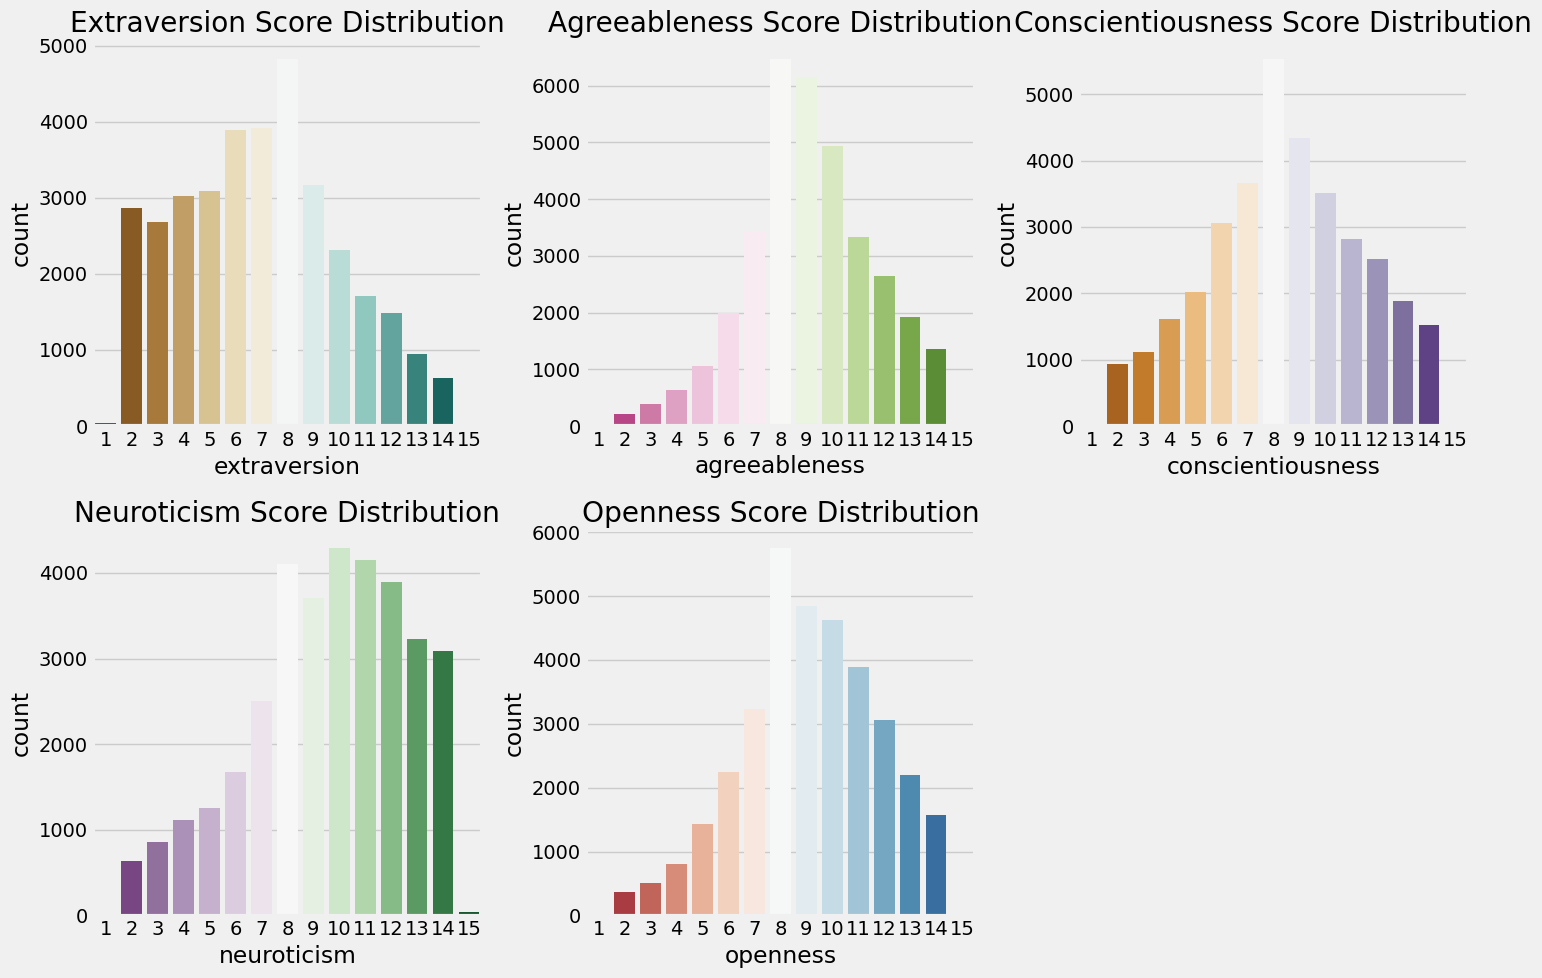

In [18]:
# Plotting distribution for each trait
plt.style.use('fivethirtyeight')
f, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plotting the engineered features
sns.countplot(x=DASS_Data['extraversion'], palette='BrBG', ax=axes[0, 0])
sns.countplot(x=DASS_Data['agreeableness'], palette="PiYG", ax=axes[0, 1])
sns.countplot(x=DASS_Data['conscientiousness'], palette='PuOr', ax=axes[0, 2])
sns.countplot(x=DASS_Data['neuroticism'], palette="PRGn", ax=axes[1, 0])
sns.countplot(x=DASS_Data['openness'], palette="RdBu", ax=axes[1, 1])

# Setting titles for a professional finish
axes[0,0].set_title('Extraversion Score Distribution')
axes[0,1].set_title('Agreeableness Score Distribution')
axes[0,2].set_title('Conscientiousness Score Distribution')
axes[1,0].set_title('Neuroticism Score Distribution')
axes[1,1].set_title('Openness Score Distribution')

# Hide the empty 6th subplot
axes[1, 2].set_visible(False)

plt.tight_layout()
plt.show()

Determining whether religion, orientation, and educational attainment are correlated with the Big Five qualities. Using the chi-squared test of independence, I have investigated the following broad hypotheses:

*   Null hypothesis (H0): The given variable (religion, orientation, or level of education) is independent of the given Big Five trait.
*   Alternative hypothesis (Ha): The given variable (religion, orientation, or level of education) is dependent on the given Big Five trait.

### Religion

In [19]:
import scipy
from scipy import stats

#constructing a contingency table for each trait
tab_religion_O =  pd.crosstab(DASS_Data['religion'], DASS_Data['openness'])
tab_religion_C =  pd.crosstab(DASS_Data['religion'], DASS_Data['conscientiousness'])
tab_religion_E =  pd.crosstab(DASS_Data['religion'], DASS_Data['extraversion'])
tab_religion_A =  pd.crosstab(DASS_Data['religion'], DASS_Data['agreeableness'])
tab_religion_N =  pd.crosstab(DASS_Data['religion'], DASS_Data['neuroticism'])

In [20]:
#building a function to neatly print each test's results
def results(chi_squared, p, dof, expected):
    print(f"Chi-Squared: {chi_squared}")
    print(f"P-value: {p}")
    print(f"Degrees of Freedom: {dof}")

In [21]:
chi_squared, p, dof, expected = stats.chi2_contingency(tab_religion_O)
print("Results of Big Five - Openness x Religion:")
results(chi_squared, p, dof, expected)

Results of Big Five - Openness x Religion:
Chi-Squared: 1514.9304830759297
P-value: 4.3552599319195985e-222
Degrees of Freedom: 154


In [22]:
chi_squared, p, dof, expected = stats.chi2_contingency(tab_religion_C)
print("Results of Big Five - Conscientiousness x Religion:")
results(chi_squared, p, dof, expected)

Results of Big Five - Conscientiousness x Religion:
Chi-Squared: 858.0850215493545
P-value: 3.533579581969696e-98
Degrees of Freedom: 154


In [23]:
chi_squared, p, dof, expected = stats.chi2_contingency(tab_religion_E)
print("Results of Big Five - Extraversion x Religion:")
results(chi_squared, p, dof, expected)

Results of Big Five - Extraversion x Religion:
Chi-Squared: 2325.363000559506
P-value: 0.0
Degrees of Freedom: 154


In [24]:
chi_squared, p, dof, expected = stats.chi2_contingency(tab_religion_C)
print("Results of Big Five - Agreeableness x Religion:")
results(chi_squared, p, dof, expected)

Results of Big Five - Agreeableness x Religion:
Chi-Squared: 858.0850215493545
P-value: 3.533579581969696e-98
Degrees of Freedom: 154


In [25]:
chi_squared, p, dof, expected = stats.chi2_contingency(tab_religion_N)
print("Results of Big Five - Neuroticism x Religion:")
results(chi_squared, p, dof, expected)

Results of Big Five - Neuroticism x Religion:
Chi-Squared: 879.5753764061719
P-value: 4.963967973496941e-102
Degrees of Freedom: 154


It can be ascertained from these tests that it is safe to reject all nulls and conclude that religion and each of the Big Five traits are dependent.

### Orientation

In [26]:
tab_orientation_O =  pd.crosstab(DASS_Data['orientation'], DASS_Data['openness'])
tab_orientation_C =  pd.crosstab(DASS_Data['orientation'], DASS_Data['conscientiousness'])
tab_orientation_E =  pd.crosstab(DASS_Data['orientation'], DASS_Data['extraversion'])
tab_orientation_A =  pd.crosstab(DASS_Data['orientation'], DASS_Data['agreeableness'])
tab_orientation_N =  pd.crosstab(DASS_Data['orientation'], DASS_Data['neuroticism'])

In [27]:
chi_squared, p, dof, expected = stats.chi2_contingency(tab_orientation_O)
print("Results of Big Five - Openness x Orientation:")
results(chi_squared, p, dof, expected)

Results of Big Five - Openness x Orientation:
Chi-Squared: 182.30358604602011
P-value: 2.752898609320976e-15
Degrees of Freedom: 56


In [28]:
chi_squared, p, dof, expected = stats.chi2_contingency(tab_orientation_C)
print("Results of Big Five - Conscientiousness x Orientation:")
results(chi_squared, p, dof, expected)

Results of Big Five - Conscientiousness x Orientation:
Chi-Squared: 233.79764788012938
P-value: 1.374119120486376e-23
Degrees of Freedom: 56


In [29]:
chi_squared, p, dof, expected = stats.chi2_contingency(tab_orientation_E)
print("Results of Big Five - Extraversion x Orientation:")
results(chi_squared, p, dof, expected)

Results of Big Five - Extraversion x Orientation:
Chi-Squared: 265.2071472504999
P-value: 6.037518643552302e-29
Degrees of Freedom: 56


In [30]:
chi_squared, p, dof, expected = stats.chi2_contingency(tab_orientation_A)
print("Results of Big Five - Agreeableness x Orientation:")
results(chi_squared, p, dof, expected)

Results of Big Five - Agreeableness x Orientation:
Chi-Squared: 115.82792040910415
P-value: 4.657669171867492e-06
Degrees of Freedom: 56


In [31]:
chi_squared, p, dof, expected = stats.chi2_contingency(tab_orientation_N)
print("Results of Big Five - Neuroticism x Orientation:")
results(chi_squared, p, dof, expected)

Results of Big Five - Neuroticism x Orientation:
Chi-Squared: 483.34217528473414
P-value: 2.540174826814976e-69
Degrees of Freedom: 56


Similarly, results tell us that it is safe to reject all nulls and conclude that orientation and each of the Big Five traits are dependent.

### Level of Education

In [32]:
tab_edu_O =  pd.crosstab(DASS_Data['education'], DASS_Data['openness'])
tab_edu_C =  pd.crosstab(DASS_Data['education'], DASS_Data['conscientiousness'])
tab_edu_E =  pd.crosstab(DASS_Data['education'], DASS_Data['extraversion'])
tab_edu_A =  pd.crosstab(DASS_Data['education'], DASS_Data['agreeableness'])
tab_edu_N =  pd.crosstab(DASS_Data['education'], DASS_Data['neuroticism'])

In [33]:
chi_squared, p, dof, expected = stats.chi2_contingency(tab_edu_O)
print("Results of Big Five - Openness x Education:")
results(chi_squared, p, dof, expected)

Results of Big Five - Openness x Education:
Chi-Squared: 383.8858189781988
P-value: 9.227164523235636e-57
Degrees of Freedom: 42


In [34]:
chi_squared, p, dof, expected = stats.chi2_contingency(tab_edu_C)
print("Results of Big Five - Conscientiousness x Education:")
results(chi_squared, p, dof, expected)

Results of Big Five - Conscientiousness x Education:
Chi-Squared: 1014.1156355834178
P-value: 3.311717461057506e-185
Degrees of Freedom: 42


In [35]:
chi_squared, p, dof, expected = stats.chi2_contingency(tab_edu_E)
print("Results of Big Five - Extraversion x Education:")
results(chi_squared, p, dof, expected)

Results of Big Five - Extraversion x Education:
Chi-Squared: 528.4597502189519
P-value: 2.1576245198731372e-85
Degrees of Freedom: 42


In [36]:
chi_squared, p, dof, expected = stats.chi2_contingency(tab_edu_A)
print("Results of Big Five - Agreeableness x Education:")
results(chi_squared, p, dof, expected)

Results of Big Five - Agreeableness x Education:
Chi-Squared: 303.1733725168466
P-value: 2.84964977535638e-41
Degrees of Freedom: 42


In [37]:
chi_squared, p, dof, expected = stats.chi2_contingency(tab_edu_N)
print("Results of Big Five - Neuroticism x Education:")
results(chi_squared, p, dof, expected)

Results of Big Five - Neuroticism x Education:
Chi-Squared: 1046.7958530363987
P-value: 4.995402126242757e-192
Degrees of Freedom: 42


Finally, results tell us that we can reject all nulls and conclude that level of education and each of the Big Five traits are dependent.

## III. Machine Learning

Using Machine learning to draw some conclusions regarding the factors that contribute to certain responses for a particular survey item, as well as predict the answers themselves.

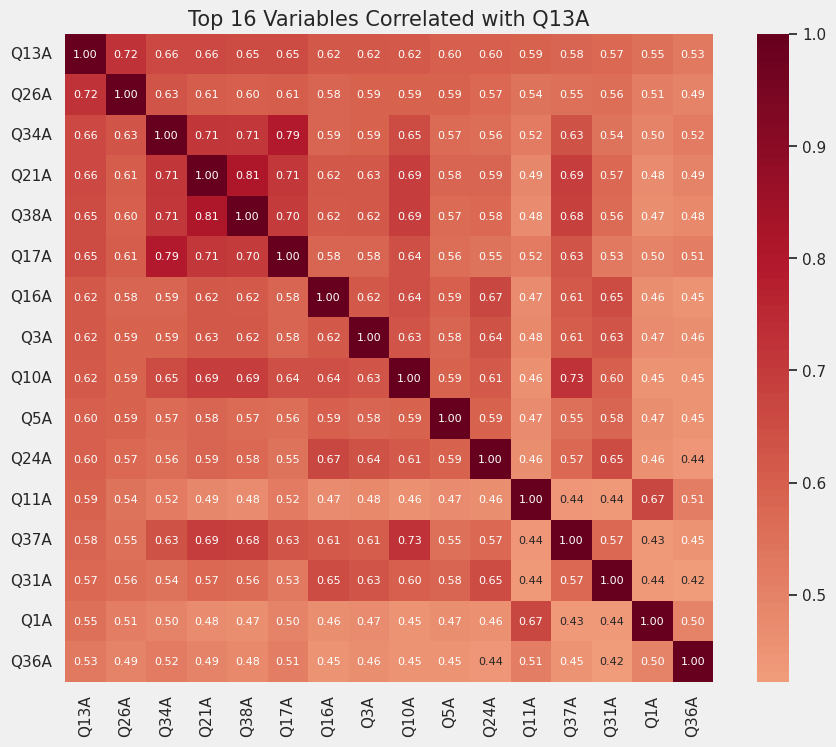

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

corrmat = DASS_Data.corr(numeric_only=True)

# 2. Find top 16 variables most correlated with Q13A (Anxiety/Stress item)
k = 16
cols = corrmat.nlargest(k, 'Q13A')['Q13A'].index

# 3. Creating the correlation matrix for just those 16 columns
cm = DASS_Data[cols].corr()

# 4. Plotting
plt.figure(figsize=(10, 8)) # Adjusted to fit screen better
sns.set(font_scale=1.0)

hm = sns.heatmap(cm,
                 cbar=True,
                 annot=True,
                 square=True,
                 fmt='.2f',
                 annot_kws={'size': 8},
                 yticklabels=cols.values,
                 xticklabels=cols.values,
                 cmap='RdBu_r', # Red-Blue palette is standard for correlations
                 center=0)

plt.title('Top 16 Variables Correlated with Q13A', fontsize=15)
plt.show()

### Preprocessing

Splitting data into a training set and a testing set, so that it is easier to validate the models' efficacy further down the line.

In [39]:
X = DASS_Data.drop(['major', 'country', 'age_group', 'Q13A'], axis =1)
y = DASS_Data['Q13A']

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=0)

### Baseline Model - Decision Tree

Before utilizing more complex models, establishing a baseline using a decision tree with a simple method left on default parameters.  

In [41]:
#importing and itiating instance of model
from sklearn.tree import DecisionTreeClassifier
DTree = DecisionTreeClassifier()

#fitting to data
DTree.fit(X_train, y_train)

DecisionTreeClassifier()

In [42]:
##classification accuracy, or percentage of correct predictions
print(DTree.score(X_test,y_test))

0.5426547137073453


This result isn't much better than a coin-toss this isn't particularly surprising given the simplicity of the model.

## Random Forest

### Hyperparameter Tuning and Model Fitting

Each model within this architecture presents a unique set of hyperparameters that directly influence scoring accuracy. To move beyond default configurations, I implemented a formal tuning phase. Given that each parameter adjustment necessitates a complete model re-fit, manual iteration was discarded in favor of a more systematic approach.

I utilized Validation Curves to map the relationship between parameter variance and model performance. This visualization allowed for the precise identification of the "sweet spot"—the juncture where the cross-validation (CV) score maximizes or plateaus before the model begins to overfit.

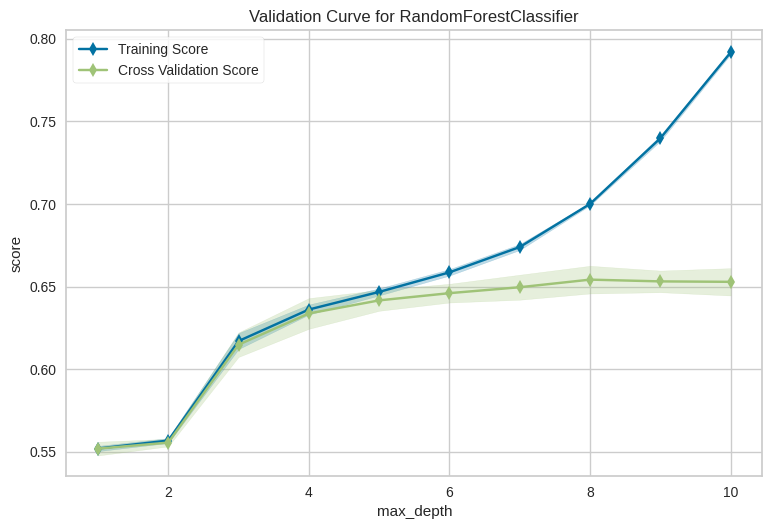

<Axes: title={'center': 'Validation Curve for RandomForestClassifier'}, xlabel='max_depth', ylabel='score'>

In [43]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from yellowbrick.model_selection import validation_curve

viz = validation_curve(
    RandomForestClassifier(), X, y,
    param_name="max_depth",
    param_range=np.arange(1, 11),
    cv=5,
    scoring="accuracy"
)

viz.show()

 CV score is plateauing at 9. Thus max_depth = 9.

In [44]:
from sklearn.ensemble import RandomForestClassifier
RFC = RandomForestClassifier(max_depth = 9, n_estimators = 150, random_state = 0)
RFC.fit(X_train, y_train)

RandomForestClassifier(max_depth=9, n_estimators=150, random_state=0)

In [45]:
print(RFC.score(X_test,y_test))

0.6519664545980336


### Evaluation

Breaking down feature importance

<Axes: xlabel='Feature'>

<Figure size 500x500 with 0 Axes>

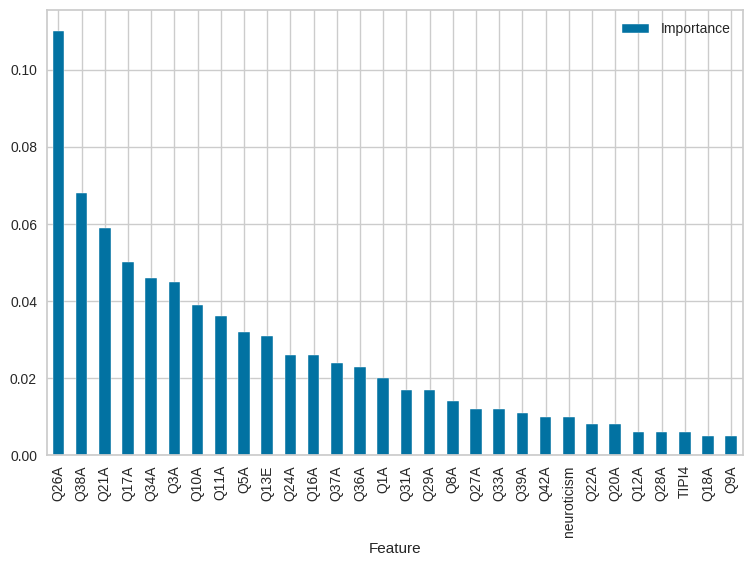

In [46]:
#considering high dimensionality,focusing on the top 30 features for the sake of plotting
feat_imp = pd.DataFrame({'Feature':X_train.columns,'Importance':np.round(RFC.feature_importances_,3)})
feat_imp = feat_imp.sort_values('Importance',ascending=False).set_index('Feature').head(30)
fig = plt.figure(figsize = (5, 5))
feat_imp.plot.bar()

In [47]:
#finding percentage of most frequent class
y_test.value_counts().head(1) / len(y_test)

,count
Q13A,
4,0.347744


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


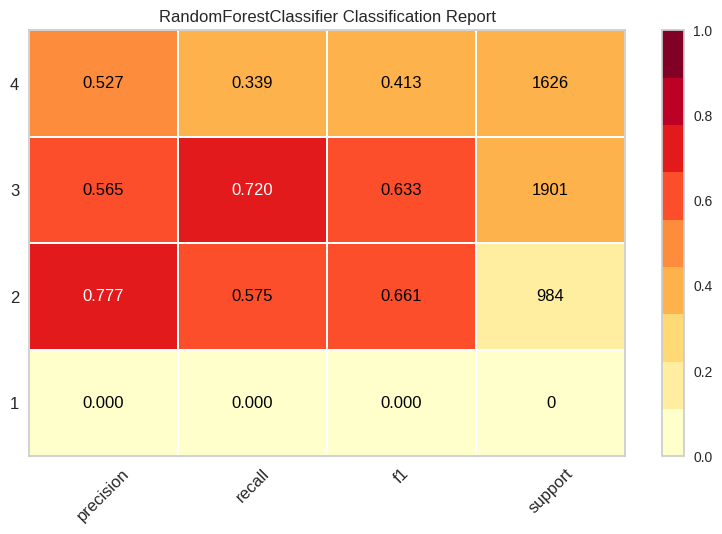

In [48]:
# printing a classification report to gain a more specific idea of how the model is performing regarding each class
from yellowbrick.classifier import classification_report

# Instantiate the visualizer
visualizer = classification_report(
    RandomForestClassifier(), X_train, y_train, X_test, y_test, support=True)

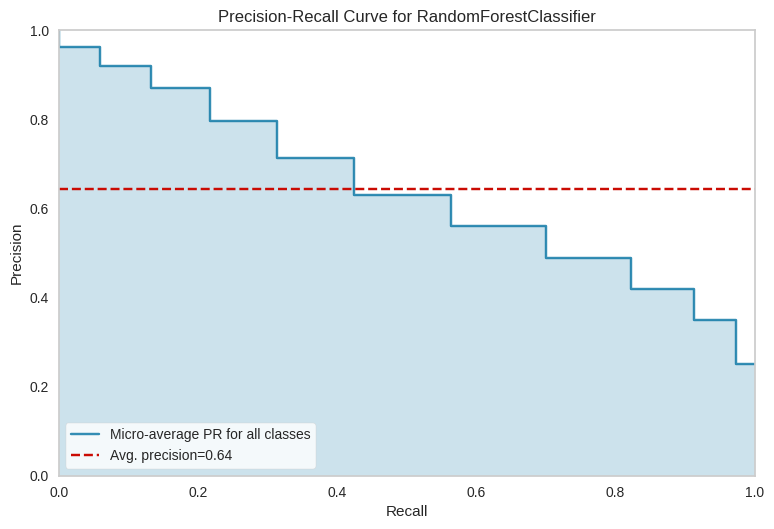

<Axes: title={'center': 'Precision-Recall Curve for RandomForestClassifier'}, xlabel='Recall', ylabel='Precision'>

In [49]:
#plotting precision-recall curve
from yellowbrick.classifier import PrecisionRecallCurve
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

X = OrdinalEncoder().fit_transform(X)
y = LabelEncoder().fit_transform(y)

viz = PrecisionRecallCurve(RandomForestClassifier(n_estimators=10))
viz.fit(X_train, y_train)
viz.score(X_test, y_test)
viz.show()

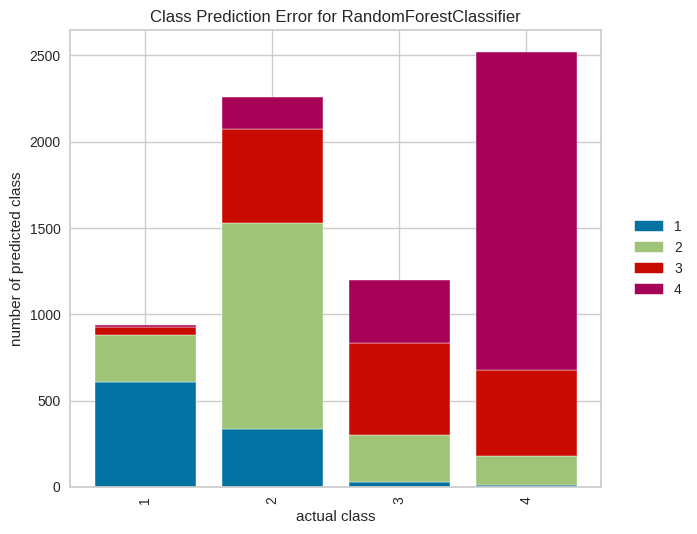

<Axes: title={'center': 'Class Prediction Error for RandomForestClassifier'}, xlabel='actual class', ylabel='number of predicted class'>

In [50]:
#plotting a histogram of the confusion matrix for more visually digestable perspective.

from yellowbrick.classifier import ClassPredictionError
# Instantiate classification model and visualizer
visualizer = ClassPredictionError(
    RandomForestClassifier(random_state=42, n_estimators=10))

# Fit training data to the visualizer
visualizer.fit(X_train, y_train)

# Evaluate model on the test data
visualizer.score(X_test, y_test)

# Draw visualization
visualizer.show()

 It appears that the model is only effectinve on classes that are more easily distinguishable from the others.
 While the overall model achieves low accurage, its ability to predict class 4 is very good.

### Cross-Validation

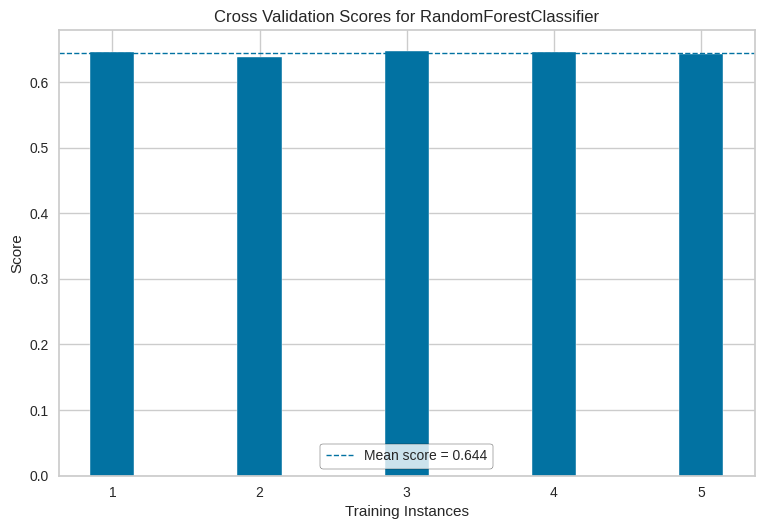

<Axes: title={'center': 'Cross Validation Scores for RandomForestClassifier'}, xlabel='Training Instances', ylabel='Score'>

In [51]:
#plotting a 5-fold CV histogram for ease of interpretation.
from sklearn.model_selection import StratifiedKFold
from yellowbrick.model_selection import CVScores

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# 2. Initialize the visualizer
visualizer = CVScores(RandomForestClassifier(), cv=cv, scoring='f1_weighted')
visualizer.fit(X, y)
visualizer.show()

## Re-evaluting Approach

Reformat the dataset into a binary classification, thus simplifying the prediction process. Grouped 1 and 2 into the "less likely" class (0), and 3 and 4 into a "more likely" class (1).

In [52]:
#regrouping
DASS_Data.loc[DASS_Data['Q13A'] <= 2, 'Q13A'] = 0
DASS_Data.loc[DASS_Data['Q13A'] >= 3, 'Q13A'] = 1

In [53]:
DASS_Data['Q13A'].value_counts()

,count
Q13A,
1,19816
0,14760


In [54]:
#resplitting
X2 = DASS_Data.drop(['major', 'country', 'age_group', 'Q13A'], axis =1)
y2 = DASS_Data['Q13A']

from sklearn.model_selection import train_test_split

X2_train, X2_test, y2_train, y2_test = train_test_split(X2,y2, test_size=0.20, random_state=0)

In [55]:
#refitting
from sklearn.ensemble import RandomForestClassifier

RFC = RandomForestClassifier(max_depth = 9, n_estimators = 150, random_state = 0)

RFC.fit(X2_train, y2_train)

RandomForestClassifier(max_depth=9, n_estimators=150, random_state=0)

In [56]:
RFC.score(X2_test, y2_test)

0.8520821283979179

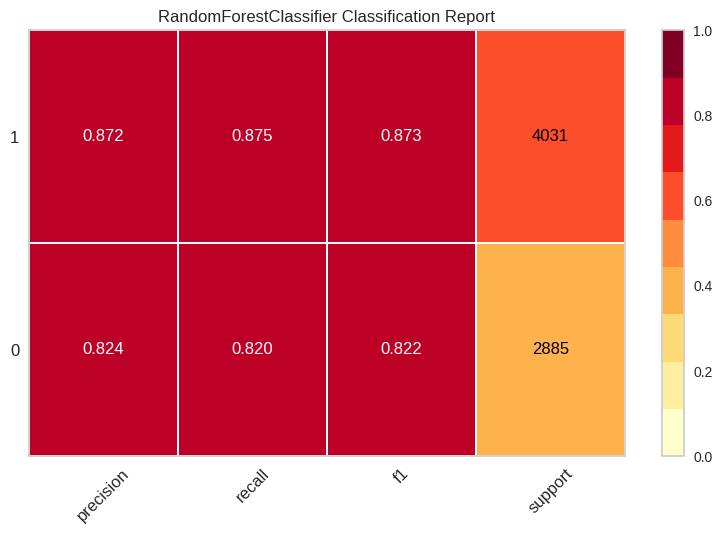

In [57]:
from yellowbrick.classifier import classification_report

# Instantiate the visualizer
visualizer = classification_report(
    RandomForestClassifier(), X2_train, y2_train, X2_test, y2_test, support=True)

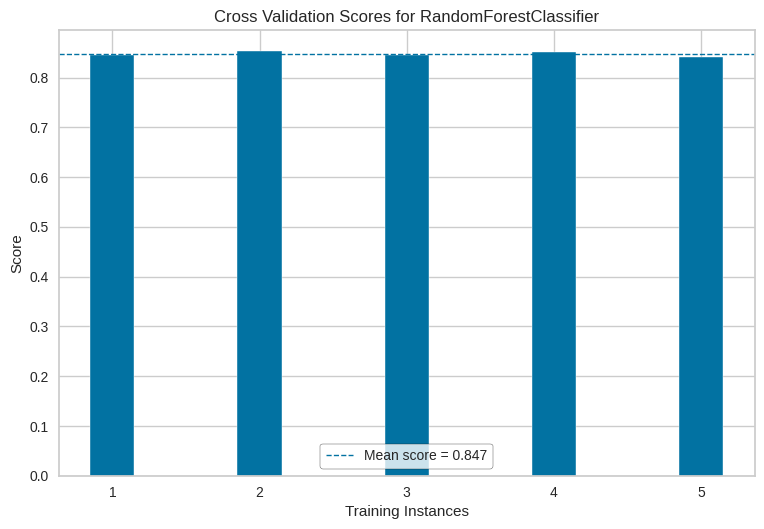

<Axes: title={'center': 'Cross Validation Scores for RandomForestClassifier'}, xlabel='Training Instances', ylabel='Score'>

In [58]:
from sklearn.model_selection import StratifiedKFold
from yellowbrick.model_selection import CVScores

# 1. THE FIX: Add shuffle=True
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# 2. Initialize the visualizer
# Note: Ensure X2 and y2 are defined in your environment
visualizer = CVScores(RandomForestClassifier(), cv=cv, scoring='f1_weighted')

visualizer.fit(X2, y2)
visualizer.show()